<a href="https://colab.research.google.com/github/sadhanakumble/DemoFirst/blob/main/Gait_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# CASIA-B GAIT RECOGNITION USING SILHOUETTES
# Dataset: GaitDatasetB-silh.zip
# Method: GEI + CNN
# ==========================================================

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: Tesla T4


In [ ]:
tf.debugging.set_log_device_placement(True)

In [ ]:
# 1. Download CASIA-B silhouette dataset

!mkdir -p /content/casia_b

!wget -O /content/casia_b/GaitDatasetB-silh.zip \
"http://www.cbsr.ia.ac.cn/GaitDatasetB-silh.zip"

--2026-05-24 08:15:56--  http://www.cbsr.ia.ac.cn/GaitDatasetB-silh.zip
Resolving www.cbsr.ia.ac.cn (www.cbsr.ia.ac.cn)... 159.226.21.60
Connecting to www.cbsr.ia.ac.cn (www.cbsr.ia.ac.cn)|159.226.21.60|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 659103200 (629M) [application/x-zip-compressed]
Saving to: ‘/content/casia_b/GaitDatasetB-silh.zip’

/content/casia_b/Ga 100%[===================>] 628.57M   341KB/s    in 32m 6s  

2026-05-24 08:48:02 (334 KB/s) - ‘/content/casia_b/GaitDatasetB-silh.zip’ saved [659103200/659103200]



In [ ]:
# 2. Unzip dataset

zip_path = "/content/casia_b/GaitDatasetB-silh.zip"
extract_path = "/content/casia_b/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
# 3. Check extracted folders

!find /content/casia_b -maxdepth 3 -type d | head -30

/content/casia_b
/content/casia_b/GaitDatasetB-silh


In [ ]:
# 4. Locate silhouette root folder

for root, dirs, files in os.walk("/content/casia_b"):
    if len(dirs) > 0:
        print(root)
        print(dirs[:10])
        break

/content/casia_b
['GaitDatasetB-silh']


In [ ]:
# 5. Set dataset root manually after checking structure

# Usually the structure may look like:
# /content/casia_b/DatasetB/silhouettes/001/nm-01/090/*.png

DATASET_ROOT = "/content/casia_b/DatasetB/silhouettes"

IMG_SIZE = (64, 64)
MAX_PERSONS = 20
SELECTED_VIEWS = ["000", "018", "036", "054", "072", "090", "108", "126", "144", "162", "180"]
SELECTED_CONDITION_PREFIX = "nm"
MAX_PERSONS = 30

In [ ]:
# 6. Function to create GEI from silhouette sequence

def create_gei(sequence_path, img_size=(64, 64)):
    frames = []

    image_files = sorted([
        f for f in os.listdir(sequence_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ])

    for img_file in image_files:
        img_path = os.path.join(sequence_path, img_file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, img_size)
        img = img / 255.0
        frames.append(img)

    if len(frames) == 0:
        return None

    gei = np.mean(np.array(frames), axis=0)
    return gei

In [ ]:
import os

for root, dirs, files in os.walk('/content/casia_b'):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

/content/casia_b
Folders: ['GaitDatasetB-silh', 'extracted_silh']
Files: ['GaitDatasetB-silh.zip']
--------------------------------------------------
/content/casia_b/GaitDatasetB-silh
Folders: []
Files: ['071.tar.gz', '082.tar.gz', '053.tar.gz', '075.tar.gz', '068.tar.gz']
--------------------------------------------------
/content/casia_b/extracted_silh
Folders: ['020', '019', '007', '003', '006']
Files: []
--------------------------------------------------
/content/casia_b/extracted_silh/020
Folders: ['nm-02', 'bg-01', 'nm-05', 'bg-02', 'nm-04']
Files: []
--------------------------------------------------
/content/casia_b/extracted_silh/020/nm-02
Folders: ['072', '162', '000', '108', '180']
Files: []
--------------------------------------------------
/content/casia_b/extracted_silh/020/nm-02/072
Folders: []
Files: ['020-nm-02-072-049.png', '020-nm-02-072-079.png', '020-nm-02-072-071.png', '020-nm-02-072-070.png', '020-nm-02-072-053.png']
---------------------------------------------

In [ ]:
DATASET_ROOT = "/content/casia_b/GaitDatasetB-silh"

In [ ]:
print(os.listdir(DATASET_ROOT)[:5])

['071.tar.gz', '082.tar.gz', '053.tar.gz', '075.tar.gz', '068.tar.gz']


In [ ]:
import os
import tarfile
from tqdm import tqdm

TAR_ROOT = "/content/casia_b/GaitDatasetB-silh"
EXTRACT_ROOT = "/content/casia_b/extracted_silh"

os.makedirs(EXTRACT_ROOT, exist_ok=True)

tar_files = sorted([
    f for f in os.listdir(TAR_ROOT)
    if f.endswith(".tar.gz")
])[:MAX_PERSONS] # Changed from [:20] to [:MAX_PERSONS]

print("Number of tar files selected:", len(tar_files))
print(tar_files[:5])

for tar_file in tqdm(tar_files):
    tar_path = os.path.join(TAR_ROOT, tar_file)

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(EXTRACT_ROOT)

print("Selected subjects extracted.")

Number of tar files selected: 30
['001.tar.gz', '002.tar.gz', '003.tar.gz', '004.tar.gz', '005.tar.gz']


  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_2428/3649042641.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_ROOT)
100%|██████████| 30/30 [01:02<00:00,  2.08s/it]

Selected subjects extracted.


In [ ]:
# Re-prepare dataset using selected persons, condition, and multiple views

X = []
y = []
label_map = {}

persons = sorted([
    p for p in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, p))
])[:MAX_PERSONS]

for label, person in enumerate(tqdm(persons, desc="Persons")):
    person_path = os.path.join(DATASET_ROOT, person)
    label_map[label] = person

    sequences = sorted(os.listdir(person_path))

    for seq in sequences:
        if not seq.startswith(SELECTED_CONDITION_PREFIX):
            continue

        for view in SELECTED_VIEWS:
            seq_path = os.path.join(person_path, seq, view)

            if not os.path.exists(seq_path):
                continue

            gei = create_gei(seq_path, IMG_SIZE)

            if gei is not None:
                X.append(gei)
                y.append(label)

X = np.array(X)
y = np.array(y)

if len(X) == 0:
    raise ValueError("No samples found. Check DATASET_ROOT, SELECTED_VIEWS, and SELECTED_CONDITION_PREFIX.")

X = X.reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)

num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", num_classes)
print("Label map:", label_map)

Persons: 100%|██████████| 30/30 [00:45<00:00,  1.52s/it]

X shape: (1974, 64, 64, 1)
y shape: (1974,)
Number of classes: 30
Label map: {0: '001', 1: '002', 2: '003', 3: '004', 4: '005', 5: '006', 6: '007', 7: '008', 8: '009', 9: '010', 10: '011', 11: '012', 12: '013', 13: '014', 14: '015', 15: '016', 16: '017', 17: '018', 18: '019', 19: '020', 20: '021', 21: '022', 22: '023', 23: '024', 24: '025', 25: '026', 26: '027', 27: '028', 28: '029', 29: '030'}


In [ ]:
# Re-train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1579
Testing samples: 395


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Smaller CNN model with BatchNormalization (re-defining for re-training with new data)
model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(64, 64, 1)),
    BatchNormalization(), # Added BatchNormalization
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(), # Added BatchNormalization
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.6),

    Dense(num_classes, activation="softmax")
])

# IMPORTANT: compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop]
)

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FloorMod in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:local

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Streaming output truncated to the last 5000 lines.
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_164645 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_164645 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_164645 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
 14/395 ━━━━━━━━━━━━━━━━

### Training History: Accuracy and Loss (with Expanded Dataset)

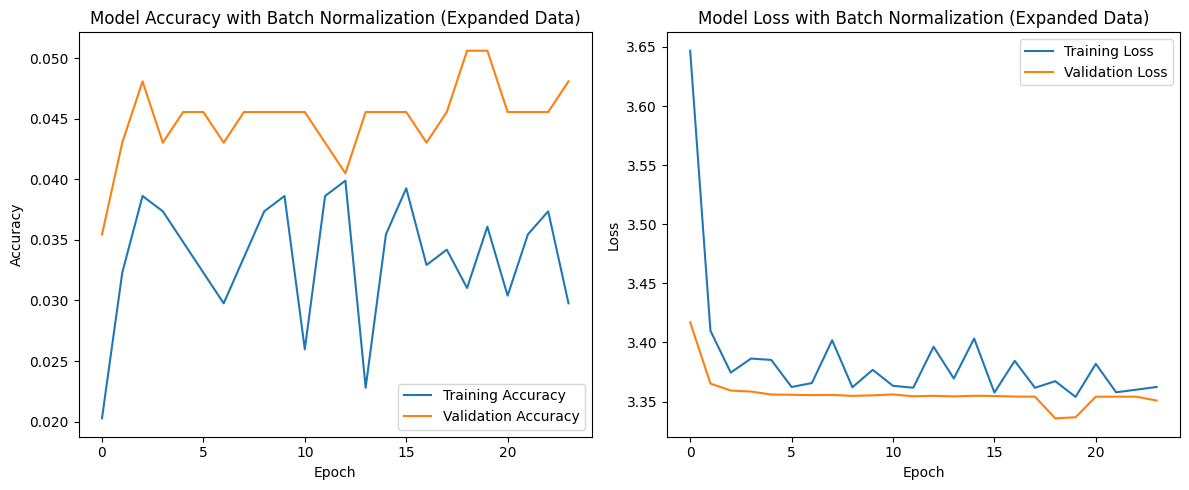

In [ ]:
import matplotlib.pyplot as plt

# Plotting accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy with Batch Normalization (Expanded Data)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss with Batch Normalization (Expanded Data)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Model Evaluation (with Expanded Dataset)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert one-hot encoded predictions and true labels to class labels
y_pred_labels = np.argmax(y_pred, axis=1);
y_true_labels = np.argmax(y_test, axis=1);

# Calculate and print metrics
accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision = precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)

print("Evaluation Metrics for Smaller CNN Model (with Batch Normalization and Expanded Data):")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true_labels, y_pred_labels))

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing o

In [ ]:
for root, dirs, files in os.walk(EXTRACT_ROOT):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 40)

    if len(files) > 0:
        break

/content/casia_b/extracted_silh
Folders: ['020', '019', '007', '003', '006']
Files: []
----------------------------------------
/content/casia_b/extracted_silh/020
Folders: ['nm-02', 'bg-01', 'nm-05', 'bg-02', 'nm-04']
Files: []
----------------------------------------
/content/casia_b/extracted_silh/020/nm-02
Folders: ['072', '162', '000', '108', '180']
Files: []
----------------------------------------
/content/casia_b/extracted_silh/020/nm-02/072
Folders: []
Files: ['020-nm-02-072-049.png', '020-nm-02-072-079.png', '020-nm-02-072-071.png', '020-nm-02-072-070.png', '020-nm-02-072-053.png']
----------------------------------------


In [ ]:
import os

possible_roots = []

for root, dirs, files in os.walk(EXTRACT_ROOT):
    if any(d.isdigit() for d in dirs):
        possible_roots.append(root)

print("Possible roots:")
for r in possible_roots[:10]:
    print(r)

Possible roots:
/content/casia_b/extracted_silh
/content/casia_b/extracted_silh/020/nm-02
/content/casia_b/extracted_silh/020/bg-01
/content/casia_b/extracted_silh/020/nm-05
/content/casia_b/extracted_silh/020/bg-02
/content/casia_b/extracted_silh/020/nm-04
/content/casia_b/extracted_silh/020/cl-02
/content/casia_b/extracted_silh/020/cl-01
/content/casia_b/extracted_silh/020/nm-03
/content/casia_b/extracted_silh/020/nm-06


In [ ]:
DATASET_ROOT = None

for root, dirs, files in os.walk(EXTRACT_ROOT):
    numeric_dirs = [d for d in dirs if d.isdigit()]

    if len(numeric_dirs) > 0:
        DATASET_ROOT = root
        break

print("DATASET_ROOT =", DATASET_ROOT)
print("Sample persons:", os.listdir(DATASET_ROOT)[:10])

DATASET_ROOT = /content/casia_b/extracted_silh
Sample persons: ['020', '019', '007', '003', '006', '013', '016', '010', '005', '012']


In [ ]:
import os

for root, dirs, files in os.walk("/content/casia_b"):
    if "001" in dirs or "002" in dirs:
        print("Possible DATASET_ROOT:", root)
        print("Sample folders:", dirs[:10])

Possible DATASET_ROOT: /content/casia_b/extracted_silh
Sample folders: ['020', '019', '007', '003', '006', '013', '016', '010', '005', '012']


In [ ]:
# 7. Prepare dataset using selected persons, condition, and multiple views

X = []
y = []
label_map = {}

persons = sorted([
    p for p in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, p))
])[:MAX_PERSONS]

for label, person in enumerate(tqdm(persons, desc="Persons")):
    person_path = os.path.join(DATASET_ROOT, person)
    label_map[label] = person

    sequences = sorted(os.listdir(person_path))

    for seq in sequences:
        if not seq.startswith(SELECTED_CONDITION_PREFIX):
            continue

        for view in SELECTED_VIEWS:
            seq_path = os.path.join(person_path, seq, view)

            if not os.path.exists(seq_path):
                continue

            gei = create_gei(seq_path, IMG_SIZE)

            if gei is not None:
                X.append(gei)
                y.append(label)

X = np.array(X)
y = np.array(y)

if len(X) == 0:
    raise ValueError("No samples found. Check DATASET_ROOT, SELECTED_VIEWS, and SELECTED_CONDITION_PREFIX.")

X = X.reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)

num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", num_classes)
print("Label map:", label_map)

Persons: 100%|██████████| 20/20 [00:29<00:00,  1.48s/it]

X shape: (1314, 64, 64, 1)
y shape: (1314,)
Number of classes: 20
Label map: {0: '001', 1: '002', 2: '003', 3: '004', 4: '005', 5: '006', 6: '007', 7: '008', 8: '009', 9: '010', 10: '011', 11: '012', 12: '013', 13: '014', 14: '015', 15: '016', 16: '017', 17: '018', 18: '019', 19: '020'}


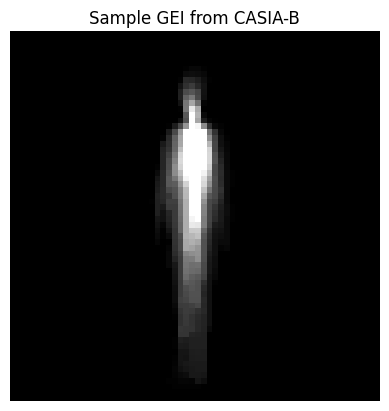

In [ ]:
# 8. Display sample GEI

plt.imshow(X[0].reshape(64, 64), cmap="gray")
plt.title("Sample GEI from CASIA-B")
plt.axis("off")
plt.show()

In [ ]:
# 9. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1051
Testing samples: 263


In [ ]:
# 10. CNN model for gait recognition

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(64, 64, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FloorMod in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:local

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,278,612 (4.88 MB)

 Trainable params: 1,278,164 (4.88 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# 11. Train model

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=8
)

Streaming output truncated to the last 5000 lines.
Executing op __inference_multi_step_on_iterator_10147 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_10147 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_10147 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
 84/132 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2252 - loss: 2.3423Executing op __inference_multi_step_on

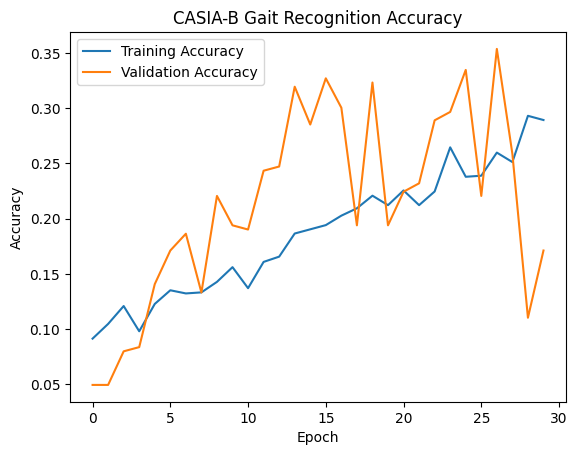

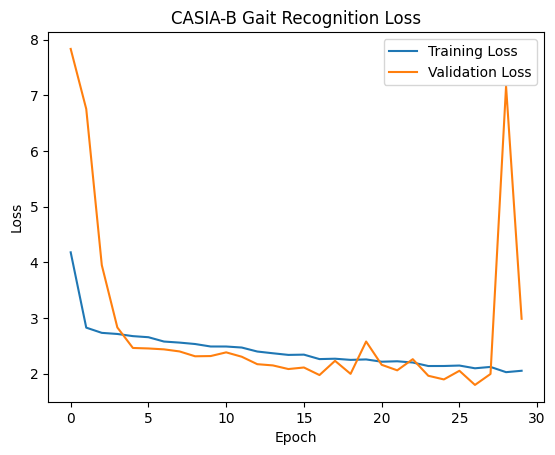

In [ ]:
# 12. Accuracy and loss graphs

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CASIA-B Gait Recognition Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CASIA-B Gait Recognition Loss")
plt.legend()
plt.show()

In [ ]:
# 13. Evaluation

y_pred = model.predict(X_test)

y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels))

print("Confusion Matrix:")
print(confusion_matrix(y_true_labels, y_pred_labels))

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing o

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 14. Save model and GEI features

model.save("/content/casia_b_gait_gei_cnn.h5")

np.save("/content/casia_b_gei_features.npy", X)
np.save("/content/casia_b_labels.npy", y)

print("Model and features saved.")

Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /j

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Convert one-hot to labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true_labels, y_pred_labels)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='weighted'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='weighted'
)

f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='weighted'
)

# Print metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true_labels, y_pred_labels))

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing o

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
MAX_PERSONS = 30
SELECTED_VIEWS = ["000", "018", "036", "054", "072", "090", "108", "126", "144", "162", "180"]
VALID_SEQUENCES = ["nm-01", "nm-02", "nm-03", "nm-04", "nm-05", "nm-06"]

In [ ]:
model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(64, 64, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.6),

    Dense(num_classes, activation="softmax")
])

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FloorMod in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in d

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FloorMod in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AddV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:loca

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Smaller CNN model with BatchNormalization
model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(64, 64, 1)),
    BatchNormalization(), # Added BatchNormalization
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(), # Added BatchNormalization
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.6),

    Dense(num_classes, activation="softmax")
])

# IMPORTANT: compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop]
)

Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FloorMod in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Cast in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:local

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Streaming output truncated to the last 5000 lines.
Executing op __inference_multi_step_on_iterator_125192 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_125192 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_125192 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalHasValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op OptionalGetValue in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op __inference_multi_step_on_iterator_125192 in device /job:localhost/replica:0/task:0/device:GPU:0

### Training History: Accuracy and Loss

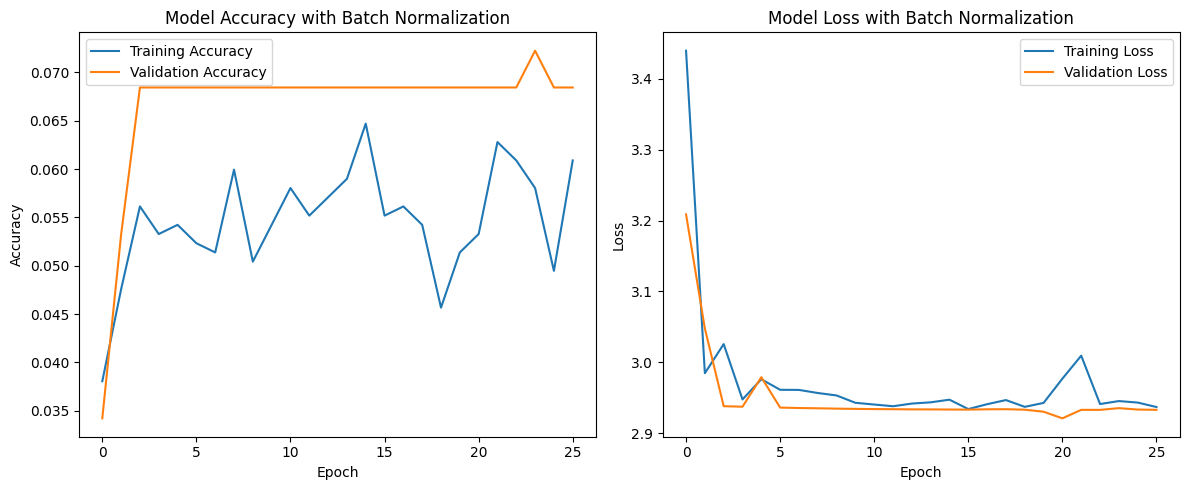

In [ ]:
import matplotlib.pyplot as plt

# Plotting accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy with Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss with Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert one-hot encoded predictions and true labels to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Calculate and print metrics
accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision = precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)

print("Evaluation Metrics for Smaller CNN Model (with Batch Normalization):")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true_labels, y_pred_labels))

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing o

In [ ]:
MAX_PERSONS = 10
SELECTED_VIEWS = ["090"]
VALID_SEQUENCES = ["nm-01", "nm-02", "nm-03", "nm-04", "nm-05", "nm-06"]

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Convert one-hot to labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true_labels, y_pred_labels)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='weighted'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='weighted'
)

f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='weighted'
)

# Print metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true_labels, y_pred_labels))

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing o

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
model.save("/content/gait_gei_cnn_baseline.h5")


Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Identity in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /j

In [ ]:
MAX_PERSONS = 10
SELECTED_VIEWS = ["090"]
VALID_SEQUENCES = ["nm-01", "nm-02", "nm-03", "nm-04", "nm-05", "nm-06"]

In [ ]:
import os

print(os.path.exists("/content/Gait.py"))

True


In [ ]:
import numpy as np

# Load y from the saved file, assuming Gait.py was trying to use it
# and there was an issue with namespace or loading within Gait.py.
y_loaded = np.load("/content/casia_b_labels.npy")

unique, counts = np.unique(y_loaded, return_counts=True)

print("Samples per class:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

Samples per class:
Class 0: 66 samples
Class 1: 66 samples
Class 2: 66 samples
Class 3: 66 samples
Class 4: 60 samples
Class 5: 66 samples
Class 6: 66 samples
Class 7: 66 samples
Class 8: 66 samples
Class 9: 66 samples
Class 10: 66 samples
Class 11: 66 samples
Class 12: 66 samples
Class 13: 66 samples
Class 14: 66 samples
Class 15: 66 samples
Class 16: 66 samples
Class 17: 66 samples
Class 18: 66 samples
Class 19: 66 samples


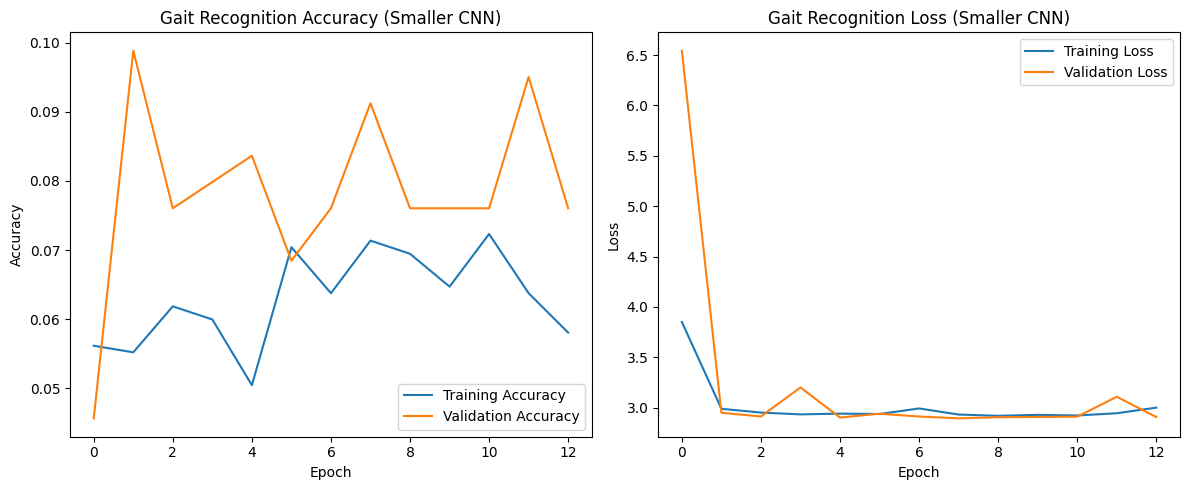

In [ ]:
import matplotlib.pyplot as plt

# 12. Accuracy and loss graphs for the new model

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Gait Recognition Accuracy (Smaller CNN)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gait Recognition Loss (Smaller CNN)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert one-hot encoded predictions and true labels to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Calculate and print metrics
accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision = precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)

print("Evaluation Metrics for Smaller CNN Model:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true_labels, y_pred_labels))

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDatasetV2 in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptionsDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing o